# 01 - Exploratory Data Analysis (EDA)
## Smart Retail Demand Forecasting & Inventory Planner

**Objective**: Perform a comprehensive inspection and exploratory data analysis of the Kaggle *Store Sales - Time Series Forecasting* dataset to understand historical demand patterns, store characteristics, macroeconomic indicators, and calendar events.

## 1. Environment Setup & Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Ensure outputs directory exists
os.makedirs("../outputs", exist_ok=True)
data_dir = "../data"

# Load datasets
train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))
stores_df = pd.read_csv(os.path.join(data_dir, "stores.csv"))
oil_df = pd.read_csv(os.path.join(data_dir, "oil.csv"))
holidays_df = pd.read_csv(os.path.join(data_dir, "holidays_events.csv"))
transactions_df = pd.read_csv(os.path.join(data_dir, "transactions.csv"))

print("All 6 datasets loaded successfully.")

All 6 datasets loaded successfully.


## 2. Dataset Overview & Data Quality Checks
Inspecting shape, column names, data types, missing values, and duplicate rows across all datasets.

In [2]:
datasets = {
    "train.csv": train_df,
    "test.csv": test_df,
    "stores.csv": stores_df,
    "oil.csv": oil_df,
    "holidays_events.csv": holidays_df,
    "transactions.csv": transactions_df
}

overview_list = []
for name, df in datasets.items():
    overview_list.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Column Names": ", ".join(df.columns)
    })

overview_table = pd.DataFrame(overview_list)
display(overview_table)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Column Names
0,train.csv,3000888,6,0,0,"id, date, store_nbr, family, sales, onpromotion"
1,test.csv,28512,5,0,0,"id, date, store_nbr, family, onpromotion"
2,stores.csv,54,5,0,0,"store_nbr, city, state, type, cluster"
3,oil.csv,1218,2,43,0,"date, dcoilwtico"
4,holidays_events.csv,350,6,0,0,"date, type, locale, locale_name, description, ..."
5,transactions.csv,83488,3,0,0,"date, store_nbr, transactions"


In [3]:
print("=== Missing Values Summary ===")
for name, df in datasets.items():
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print(f"\n{name}:")
        print(nulls[nulls > 0])
    else:
        print(f"{name}: No missing values")

=== Missing Values Summary ===


train.csv: No missing values
test.csv: No missing values
stores.csv: No missing values

oil.csv:
dcoilwtico    43
dtype: int64
holidays_events.csv: No missing values
transactions.csv: No missing values


## 3. Date Parsing & High-Level Metrics for Sales (`train.csv`)

In [4]:
# Convert date columns to pandas datetime
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])
oil_df["date"] = pd.to_datetime(oil_df["date"])
holidays_df["date"] = pd.to_datetime(holidays_df["date"])
transactions_df["date"] = pd.to_datetime(transactions_df["date"])

# High-level train metrics
min_date = train_df["date"].min()
max_date = train_df["date"].max()
unique_stores = train_df["store_nbr"].nunique()
unique_families = train_df["family"].nunique()
total_sales = train_df["sales"].sum()
avg_daily_sales = train_df.groupby("date")["sales"].sum().mean()
min_sales = train_df["sales"].min()
max_sales = train_df["sales"].max()
promo_records = (train_df["onpromotion"] > 0).sum()
total_promo_items = train_df["onpromotion"].sum()

print(f"Train Date Range           : {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')} ({(max_date - min_date).days + 1} days)")
print(f"Test Date Range            : {test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')} ({(test_df['date'].max() - test_df['date'].min()).days + 1} days)")
print(f"Unique Stores              : {unique_stores}")
print(f"Unique Product Families    : {unique_families}")
print(f"Total Historical Sales     : {total_sales:,.2f}")
print(f"Average Total Daily Sales  : {avg_daily_sales:,.2f}")
print(f"Min Sales per Record       : {min_sales}")
print(f"Max Sales per Record       : {max_sales:,.2f}")
print(f"Records with Promotions >0 : {promo_records:,} ({promo_records/len(train_df)*100:.2f}% of dataset)")
print(f"Total On-Promotion Items   : {total_promo_items:,}")

Train Date Range           : 2013-01-01 to 2017-08-15 (1688 days)
Test Date Range            : 2017-08-16 to 2017-08-31 (16 days)
Unique Stores              : 54
Unique Product Families    : 33
Total Historical Sales     : 1,073,644,952.20
Average Total Daily Sales  : 637,556.38
Min Sales per Record       : 0.0
Max Sales per Record       : 124,717.00
Records with Promotions >0 : 611,329 (20.37% of dataset)
Total On-Promotion Items   : 7,810,622


## 4. Visualizations & Pattern Analysis

### 4.1 Total Daily Sales Over Time

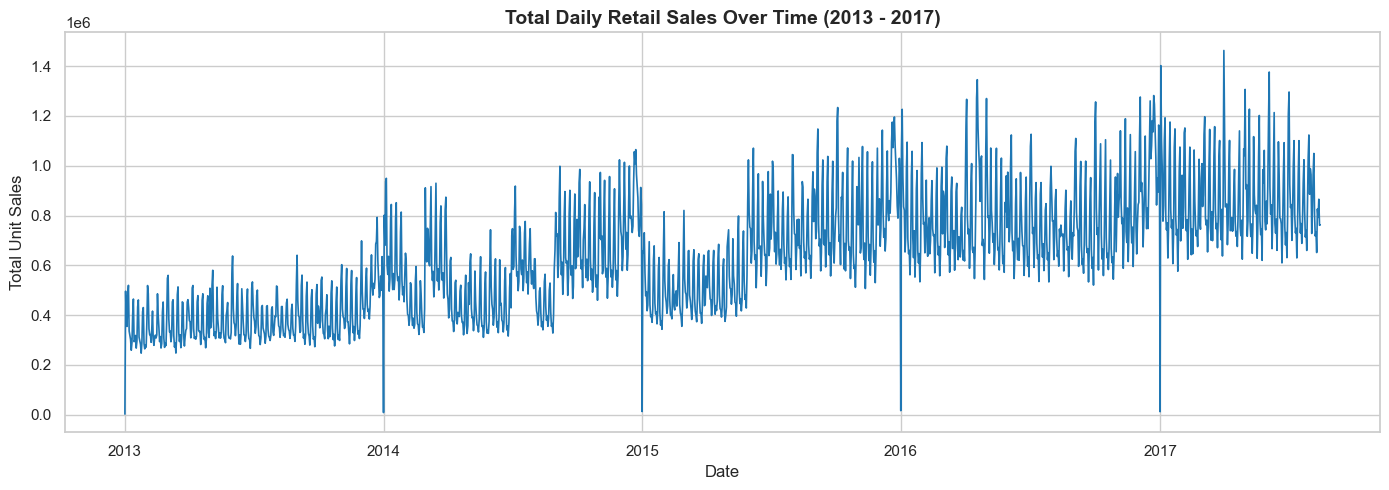

In [5]:
daily_sales = train_df.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["sales"], color="#1f77b4", linewidth=1.2)
plt.title("Total Daily Retail Sales Over Time (2013 - 2017)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Unit Sales", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/daily_sales_over_time.png", dpi=300)
plt.show()

### 4.2 Monthly Sales Trends

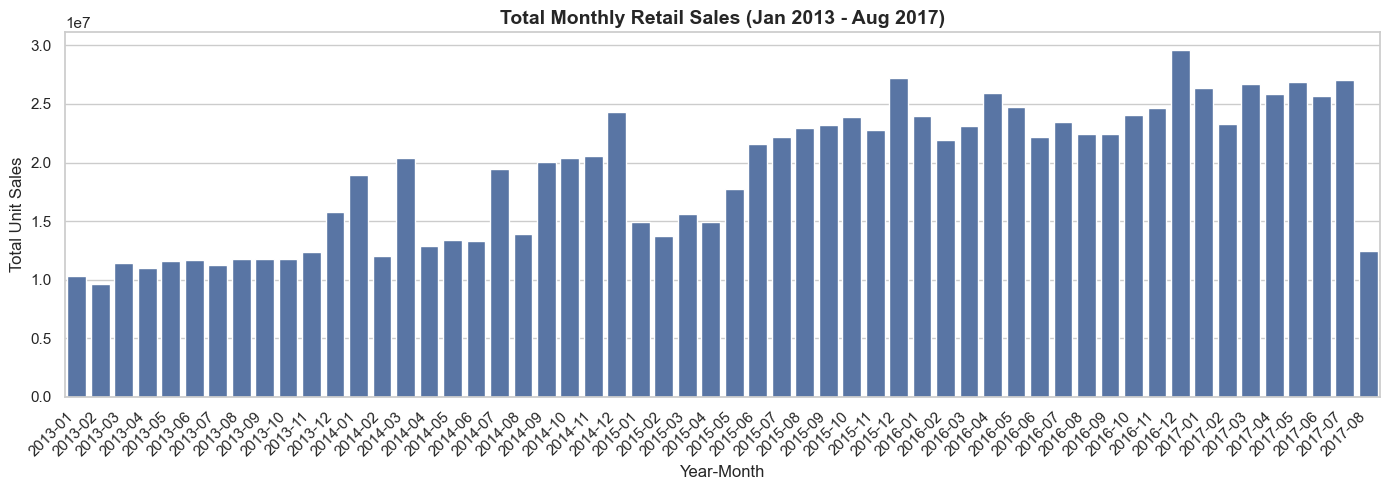

In [6]:
train_df["year_month"] = train_df["date"].dt.to_period("M")
monthly_sales = train_df.groupby("year_month")["sales"].sum().reset_index()
monthly_sales["year_month"] = monthly_sales["year_month"].astype(str)

plt.figure(figsize=(14, 5))
sns.barplot(data=monthly_sales, x="year_month", y="sales", color="#4c72b0")
plt.xticks(rotation=45, ha="right")
plt.title("Total Monthly Retail Sales (Jan 2013 - Aug 2017)", fontsize=14, fontweight="bold")
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Unit Sales", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/monthly_sales.png", dpi=300)
plt.show()

### 4.3 Sales by Product Family

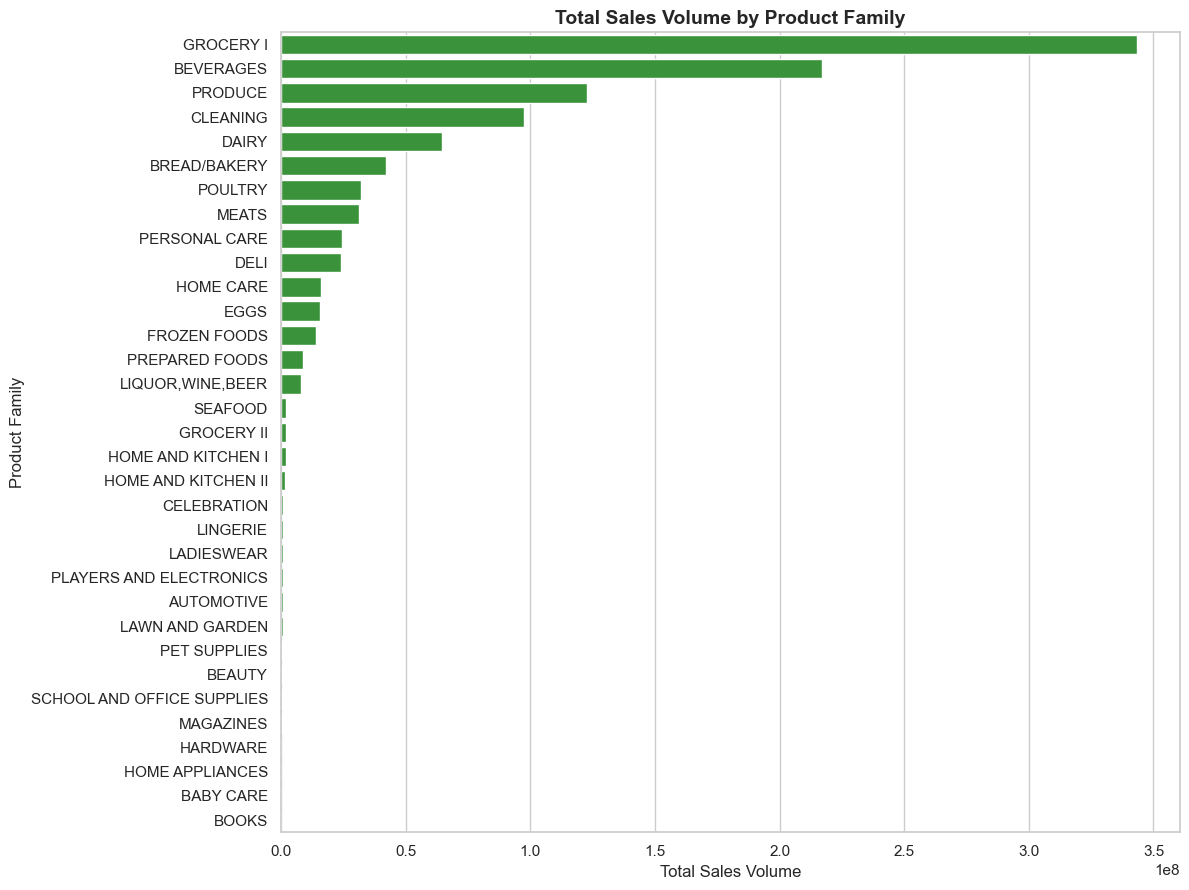

In [7]:
family_sales = train_df.groupby("family")["sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 9))
sns.barplot(data=family_sales, y="family", x="sales", color="#2ca02c")
plt.title("Total Sales Volume by Product Family", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales Volume", fontsize=12)
plt.ylabel("Product Family", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/sales_by_product_family.png", dpi=300)
plt.show()

### 4.4 Sales by Store

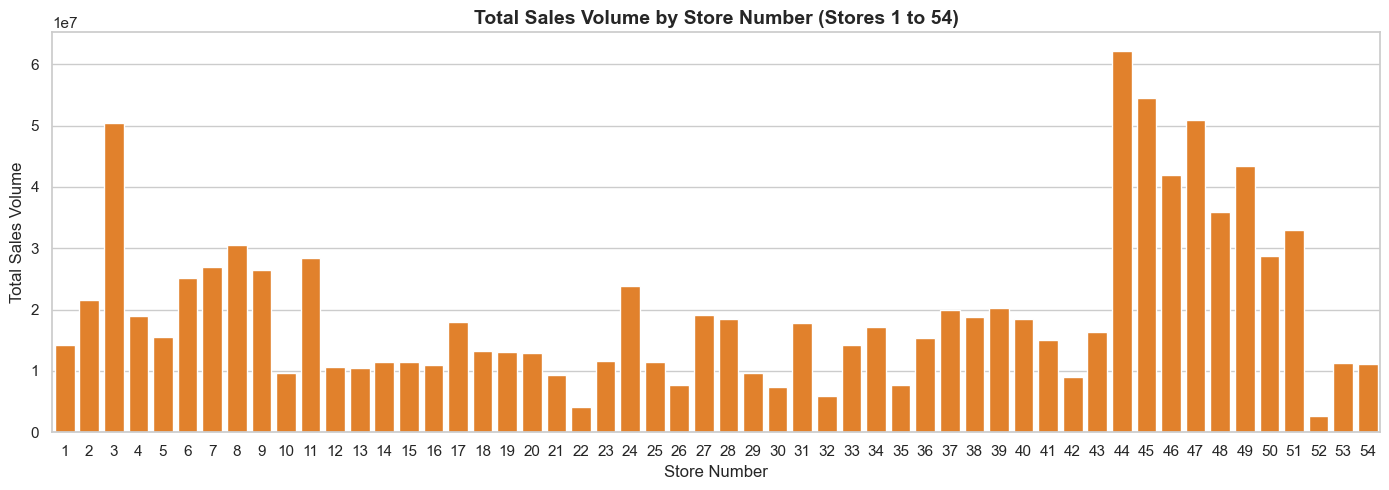

In [8]:
store_sales = train_df.groupby("store_nbr")["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.barplot(data=store_sales, x="store_nbr", y="sales", color="#ff7f0e")
plt.title("Total Sales Volume by Store Number (Stores 1 to 54)", fontsize=14, fontweight="bold")
plt.xlabel("Store Number", fontsize=12)
plt.ylabel("Total Sales Volume", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/sales_by_store.png", dpi=300)
plt.show()

### 4.5 Promotion vs Sales Impact

C:\Users\osra8\AppData\Local\Temp\ipykernel_15956\2476324567.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promo_sales = train_df.groupby(pd.cut(train_df["onpromotion"], bins=[-1, 0, 5, 20, 50, 1000], labels=["0", "1-5", "6-20", "21-50", "50+"]))["sales"].mean().reset_index()


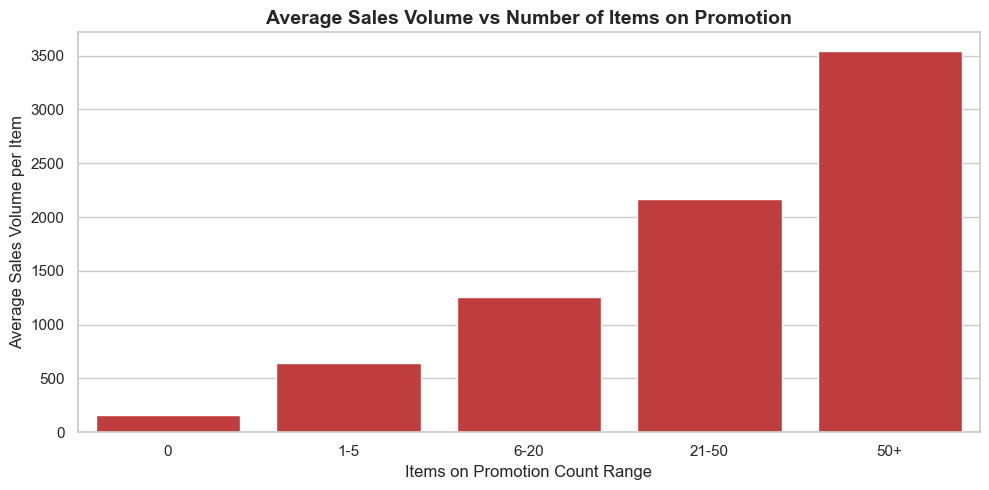

In [9]:
promo_sales = train_df.groupby(pd.cut(train_df["onpromotion"], bins=[-1, 0, 5, 20, 50, 1000], labels=["0", "1-5", "6-20", "21-50", "50+"]))["sales"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=promo_sales, x="onpromotion", y="sales", color="#d62728")
plt.title("Average Sales Volume vs Number of Items on Promotion", fontsize=14, fontweight="bold")
plt.xlabel("Items on Promotion Count Range", fontsize=12)
plt.ylabel("Average Sales Volume per Item", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/promotion_vs_sales.png", dpi=300)
plt.show()

### 4.6 Day-of-Week Sales Pattern

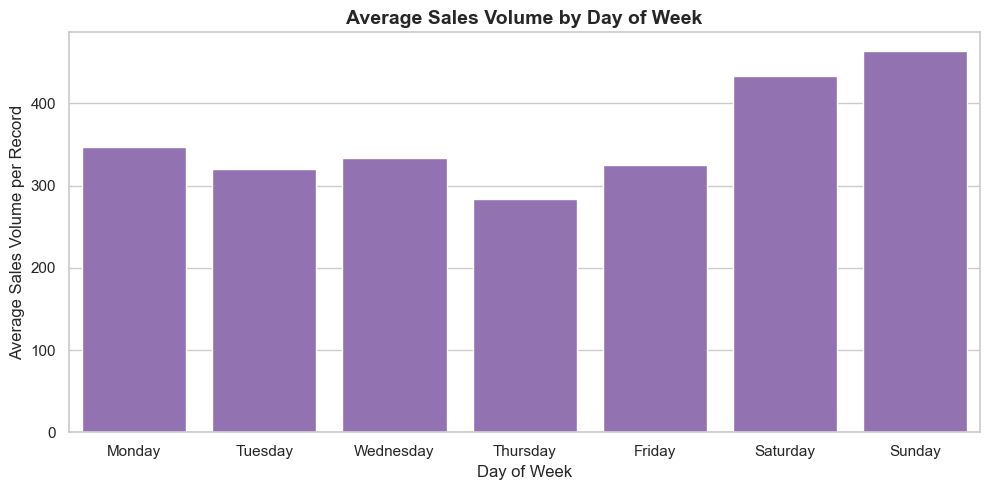

In [10]:
train_df["day_of_week"] = train_df["date"].dt.day_name()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = train_df.groupby("day_of_week")["sales"].mean().reindex(days_order).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=dow_sales, x="day_of_week", y="sales", color="#9467bd")
plt.title("Average Sales Volume by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Average Sales Volume per Record", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/day_of_week_sales.png", dpi=300)
plt.show()

### 4.7 Monthly / Seasonal Sales Pattern

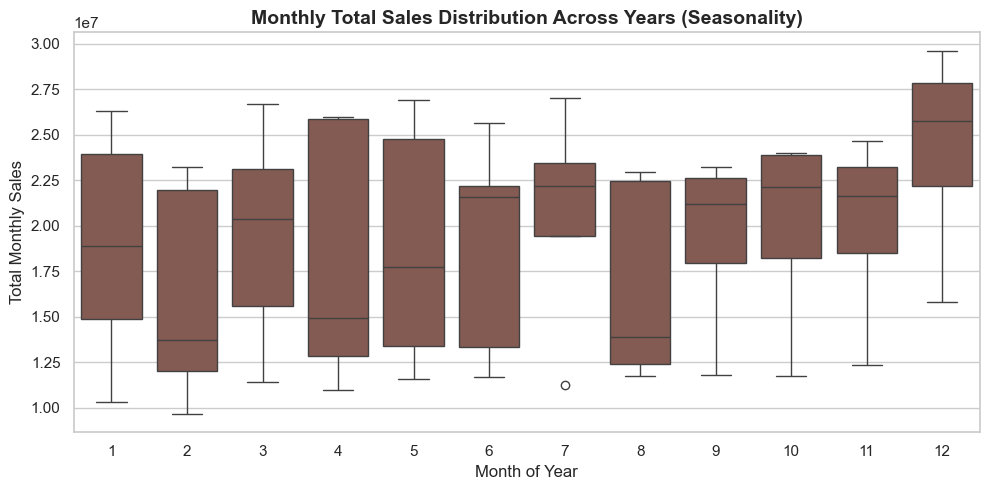

In [11]:
train_df["month"] = train_df["date"].dt.month
monthly_pattern = train_df.groupby(["year_month", "month"])["sales"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.boxplot(data=monthly_pattern, x="month", y="sales", color="#8c564b")
plt.title("Monthly Total Sales Distribution Across Years (Seasonality)", fontsize=14, fontweight="bold")
plt.xlabel("Month of Year", fontsize=12)
plt.ylabel("Total Monthly Sales", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/seasonal_sales.png", dpi=300)
plt.show()

## 5. Supplementary Dataset Analysis & Feature Utility

### 5.1 Holidays & Events Dataset Analysis
- **Structure**: Contains `date`, `type`, `locale`, `locale_name`, `description`, and `transferred`.
- **Join Utility**: Can be joined with sales data on `date` and location (`locale_name` matching `city` or `state` in `stores.csv` for local/regional holidays, or national holidays applying to all stores).
- **Key Nuance**: `transferred == True` indicates that the holiday was moved to another date. The actual non-working holiday is represented by a separate row with `type == 'Transfer'`. Correct feature engineering must account for transferred vs active holiday dates.

In [12]:
print("Holidays by Locale:")
display(holidays_df["locale"].value_counts())
print("\nHolidays by Type:")
display(holidays_df["type"].value_counts())
print(f"\nTransferred Holidays Count: {holidays_df['transferred'].sum()}")

Holidays by Locale:


locale
National    174
Local       152
Regional     24
Name: count, dtype: int64


Holidays by Type:


type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64


Transferred Holidays Count: 12


### 5.2 Stores Metadata Analysis
- **Structure**: Contains `store_nbr`, `city`, `state`, `type`, and `cluster` (17 store clusters).
- **Utility**: Essential for store grouping, categorical embeddings/one-hot encoding, and linking regional oil impact or local holidays to individual stores.

In [13]:
print("Store Types Distribution:")
display(stores_df["type"].value_counts())
print("\nStore Clusters Distribution:")
display(stores_df["cluster"].value_counts().sort_index())

Store Types Distribution:


type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64


Store Clusters Distribution:


cluster
1     3
2     2
3     7
4     3
5     1
6     6
7     2
8     3
9     2
10    6
11    3
12    1
13    4
14    4
15    5
16    1
17    1
Name: count, dtype: int64

### 5.3 Economic & Foot Traffic Data: Oil Prices & Transactions
- **Oil Price (`oil.csv`)**:
  - WTI Crude Oil price (`dcoilwtico`). Crucial macro factor for Ecuador (an oil-dependent economy).
  - Has **43 missing values** due to non-trading days/weekends.
  - Can be interpolated/forward-filled and used as a global feature.
- **Transactions (`transactions.csv`)**:
  - Daily store foot traffic count.
  - **Utility Limitation**: Highly correlated with sales during training, but **NOT available in `test.csv`**. Thus, transactions cannot be directly used as an input feature for test inference unless forecasted separately.

In [14]:
print(f"Oil price missing dates: {oil_df['dcoilwtico'].isnull().sum()}")
print(f"Oil date range: {oil_df['date'].min().strftime('%Y-%m-%d')} to {oil_df['date'].max().strftime('%Y-%m-%d')}")
print(f"Transactions date range: {transactions_df['date'].min().strftime('%Y-%m-%d')} to {transactions_df['date'].max().strftime('%Y-%m-%d')}")

Oil price missing dates: 43
Oil date range: 2013-01-01 to 2017-08-31
Transactions date range: 2013-01-01 to 2017-08-15


## 6. EDA Findings & Summary

### 1. Important Trends & Growth
- **Long-term Upward Growth**: Total retail sales show steady overall year-over-year growth from 2013 through 2017.
- **Top Product Families**: `GROCERY I`, `BEVERAGES`, `CLEANING`, and `PRODUCE` account for the vast majority (>70%) of total sales volume.
- **Store Variance**: Major store volume differences exist across store types (Type A & D stores lead in volume).

### 2. Seasonality & Periodic Patterns
- **Weekly Seasonality**: Strong weekly pattern with peak sales occurring on **Sundays** and **Saturdays**, and lowest sales on **Thursdays**.
- **Annual / Holiday Seasonality**: Significant demand spikes in **December** (Christmas / Year-end shopping), followed by a dip in early January.
- **New Year Closure**: On **January 1st** of every year, sales drop to near zero across almost all stores due to holiday closures.

### 3. Promotion Effects
- Higher `onpromotion` counts correlate strongly with increased sales volume, demonstrating that promotional items are strong drivers of demand.

### 4. Anomalies & Data Quality Concerns
- **April 2016 Earthquake Spike**: A magnitude 7.8 earthquake struck Ecuador on April 16, 2016. There is a dramatic demand surge for emergency staples (groceries, water, cleaning products) in late April 2016.
- **Missing Oil Prices**: 43 dates in `oil.csv` have missing values requiring linear interpolation or forward-filling.
- **Unavailable Test Transactions**: `transactions.csv` ends on 2017-08-15 and cannot be used directly as a feature for test forecasting.
- **Transferred Holidays**: Care is required when merging `holidays_events.csv` to ensure `transferred` flag is respected.

### 5. Key Candidate Features for Future Modeling
1. **Calendar Features**: Day of week, month, day of month, year, day of year.
2. **Lag & Rolling Window Statistics**: Sales lags (e.g., 16-day lag, 28-day lag), rolling mean, rolling std.
3. **Store & Product Categoricals**: `store_nbr`, `family`, `city`, `state`, `type`, `cluster`.
4. **Promotion Features**: `onpromotion` item counts, lag of promotion status.
5. **Holiday / Event Indicators**: Binary indicators for national/regional/local holidays, payday indicator (15th and end of month).
6. **Macro Features**: Interpolated oil price (`dcoilwtico`) and oil price rolling trends.